In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store


In [11]:
import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv')

In [14]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [15]:
print(df.shape)
print(df.columns)

df.info()

(67501979, 9)
Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 4.5+ GB


In [16]:
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    21898171
brand             9224078
price                   0
user_id                 0
user_session           10
dtype: int64

In [17]:
df = df.drop_duplicates()

In [19]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [24]:
print("Visit")
print("  ↓")
print("Product View")
print("  ↓")
print("Add to Cart")
print("  ↓")
print("Purchase")

Visit
  ↓
Product View
  ↓
Add to Cart
  ↓
Purchase


In [27]:
# Count unique users by event type
event_users = df.groupby('event_type')['user_id'].nunique()

print(event_users)

event_type
cart         826323
purchase     441638
view        3695598
Name: user_id, dtype: int64


In [28]:
view_users = event_users.get('view', 0)
cart_users = event_users.get('cart', 0)
purchase_users = event_users.get('purchase', 0)

print("Views:", view_users)
print("Cart:", cart_users)
print("Purchase:", purchase_users)

Views: 3695598
Cart: 826323
Purchase: 441638


In [29]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv',
    usecols=['event_type', 'user_id']
)

In [30]:
view_users = 3695598
cart_users = 826323
purchase_users = 441638

view_to_cart = (cart_users / view_users) * 100
cart_to_purchase = (purchase_users / cart_users) * 100
overall_conversion = (purchase_users / view_users) * 100

print(f"View → Cart Conversion Rate: {view_to_cart:.2f}%")
print(f"Cart → Purchase Conversion Rate: {cart_to_purchase:.2f}%")
print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

View → Cart Conversion Rate: 22.36%
Cart → Purchase Conversion Rate: 53.45%
Overall Conversion Rate: 11.95%


In [31]:
drop_view_cart = view_users - cart_users
drop_cart_purchase = cart_users - purchase_users

print("Drop-off from View to Cart:", drop_view_cart)
print("Drop-off from Cart to Purchase:", drop_cart_purchase)

Drop-off from View to Cart: 2869275
Drop-off from Cart to Purchase: 384685


In [32]:
funnel = pd.DataFrame({
    'Stage': ['Product View', 'Add to Cart', 'Purchase'],
    'Users': [view_users, cart_users, purchase_users]
})

funnel['Drop-off'] = funnel['Users'].shift(1) - funnel['Users']
funnel['Drop-off'] = funnel['Drop-off'].fillna(0).astype(int)

funnel

,Stage,Users,Drop-off
0,Product View,3695598,0
1,Add to Cart,826323,2869275
2,Purchase,441638,384685


In [33]:
largest_drop = funnel.iloc[1]

print("Biggest Bottleneck:")
print(largest_drop)

Biggest Bottleneck:
Stage       Add to Cart
Users            826323
Drop-off        2869275
Name: 1, dtype: object


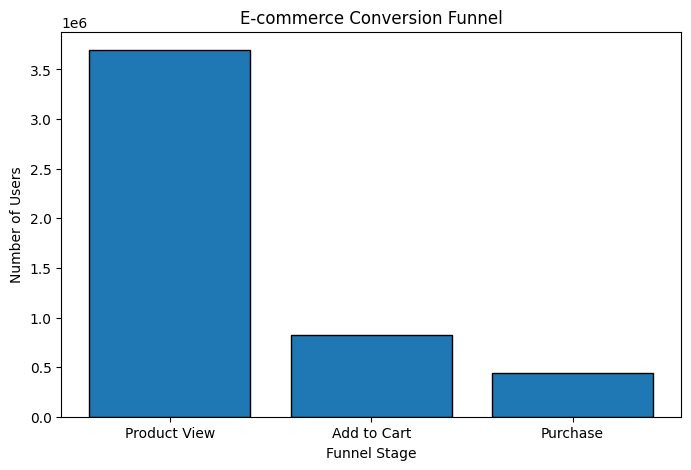

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    funnel['Stage'],
    funnel['Users'],
    edgecolor='black'
)

plt.title('E-commerce Conversion Funnel')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Users')

plt.show()

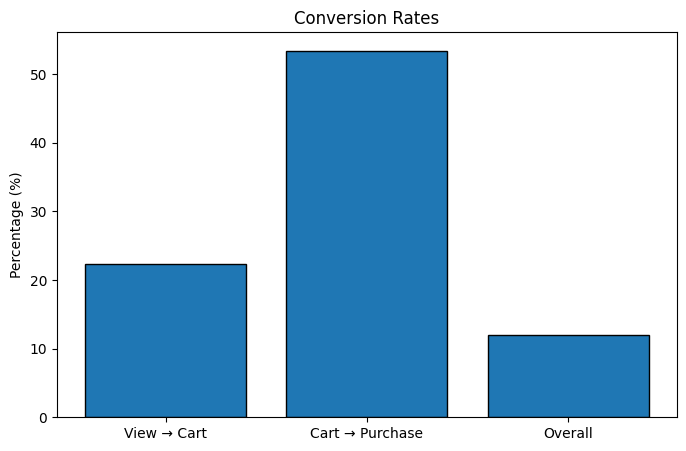

In [35]:
conversion = pd.DataFrame({
    'Stage': ['View → Cart', 'Cart → Purchase', 'Overall'],
    'Rate (%)': [view_to_cart, cart_to_purchase, overall_conversion]
})

plt.figure(figsize=(8,5))

plt.bar(
    conversion['Stage'],
    conversion['Rate (%)'],
    edgecolor='black'
)

plt.title('Conversion Rates')
plt.ylabel('Percentage (%)')

plt.show()

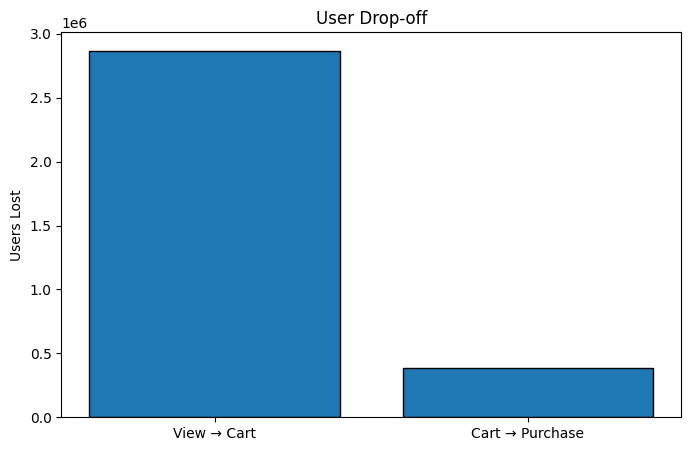

In [36]:
drop = pd.DataFrame({
    'Stage': ['View → Cart', 'Cart → Purchase'],
    'Users Lost': [drop_view_cart, drop_cart_purchase]
})

plt.figure(figsize=(8,5))

plt.bar(
    drop['Stage'],
    drop['Users Lost'],
    edgecolor='black'
)

plt.title('User Drop-off')
plt.ylabel('Users Lost')

plt.show()

Analysis

The largest bottleneck occurs between Product View and Add to Cart, where 2,869,275 users leave the funnel without adding a product to their cart. This indicates that many visitors browse products but do not take the next step toward purchasing.

Marketing Recommendations

Funnel Stage    Recommendation
Product View	Improve product images, descriptions, pricing, ratings, and reviews.
Product View	Personalize product recommendations based on browsing history.
Add to Cart	    Offer free shipping thresholds and limited-time discounts.
Checkout	    Simplify checkout, enable guest checkout, and provide multiple payment options.
Retention	    Send abandoned cart reminder emails or notifications with personalized offers.

Project Conclusion
Product Views: 3,695,598
Add to Cart: 826,323
Purchases: 441,638
Overall Conversion Rate: 11.95%

The analysis shows that the largest loss of users occurs between the Product View and Add to Cart stages, indicating that customers are interested in products but are not sufficiently motivated to add them to their carts. Improving product presentation, pricing transparency, promotions, and personalization could significantly increase conversions. The Cart to Purchase conversion rate (53.45%) is relatively strong, suggesting that once customers add items to their carts, more than half complete their purchases.

SYNTECXHUB INTERNSHIP PROJECT 3(1)-E-commerce Conversion Funnel Analysis
BY OZOJI CORNELIUS OGECHUKWU